In [3]:
import os

import json

import pandas as pd

from pandas.core.indexers import objects



# Define paths to the hard-mode raw files sitting on your laptop

SOCIAL_FILE = "C:\\Users\\yashi\\OneDrive\\Desktop\\Project_TCS\\source_social_media2\\twitter_dump.csv"

ECOMM_FILE = "C:\\Users\\yashi\\OneDrive\\Desktop\\Project_TCS\\source_ecommerce2\\web_reviews.json"

SUPPORT_FILE = "C:\\Users\\yashi\\OneDrive\\Desktop\\Project_TCS\\source_support_center2\\support_logs.csv"



# This list will hold all records before we turn it into a single DataFrame

master_records = []



print("🔄 Starting multi-channel aggregation pipeline...\n")



# ---------------------------------------------------------------------

# CHANNEL 1: Ingesting Social Media (Twitter CSV)

# Schema: [timestamp, handle, tweet_text]

# ---------------------------------------------------------------------

if os.path.exists(SOCIAL_FILE):

    df_social = pd.read_csv(SOCIAL_FILE)

    df_social["clean_timestamp"] = pd.to_datetime(df_social["timestamp"], errors='coerce')

    for idx, row in df_social.iterrows():

        master_records.append({

            "customer_id": row["customer_id"],

            "timestamp": row["clean_timestamp"],            # Target 1: Time

            "channel": "Social Media (X/Twitter)",     # Target 2: Origin Source

            "raw_text": row["tweet_text"]             # Target 3: Clean Text

        })

    print(f"📥 Successfully aggregated {len(df_social)} records from Social Media.")



# ---------------------------------------------------------------------

# CHANNEL 2: Ingesting E-Commerce Reviews (JSON Array)

# Schema: [{"review_date": ..., "rating": ..., "body": ...}]

# ---------------------------------------------------------------------

if os.path.exists(ECOMM_FILE):

    with open(ECOMM_FILE, "r", encoding="utf-8") as f:

        ecomm_data = json.load(f)

       

    for item in ecomm_data:

        cleaned_dates = pd.to_datetime(item["review_date"], format="%d-%b-%Y", errors='coerce')

        master_records.append({

            "customer_id":item["customer_id"],

            "timestamp": cleaned_dates,         # Target 1: Time (Needs formatting later)

            "channel": "E-Commerce Website",          # Target 2: Origin Source

            "raw_text": item["body"]                  # Target 3: Clean Text

        })

    print(f"📥 Successfully aggregated {len(ecomm_data)} records from E-Commerce.")



# ---------------------------------------------------------------------

# CHANNEL 3: Ingesting Customer Support Center (Logs CSV)

# Schema: [date_string, transcript]

# ---------------------------------------------------------------------

if os.path.exists(SUPPORT_FILE):

    df_support = pd.read_csv(SUPPORT_FILE)

    df_support["clean_timestamp"] = pd.to_datetime(df_support["date_string"], errors='coerce')

    for idx,row in df_support.iterrows():

        master_records.append({

            "customer_id": row["customer_id"],

            "timestamp": row["clean_timestamp"],          # Target 1: Time

            "channel": "Call Center Transcript",      # Target 2: Origin Source

            "raw_text": row["transcript"]             # Target 3: Clean Text

        })

    print(f"📥 Successfully aggregated {len(df_support)} records from Support Logs.") 



🔄 Starting multi-channel aggregation pipeline...

📥 Successfully aggregated 172 records from Social Media.
📥 Successfully aggregated 166 records from E-Commerce.
📥 Successfully aggregated 145 records from Support Logs.


In [4]:
# Turn our unified list of dictionaries into a master Pandas DataFrame
df = pd.DataFrame(master_records)
df

,customer_id,timestamp,channel,raw_text
0,1085,2024-06-01 13:51:00,Social Media (X/Twitter),The digital membership scanner loaded the basi...
1,4724,2024-06-01 10:40:00,Social Media (X/Twitter),The digital checkout screen is incredibly intu...
2,7601,2024-06-01 13:17:00,Social Media (X/Twitter),The cardboard shipping box arrived completely ...
3,2241,2024-06-01 15:05:00,Social Media (X/Twitter),The order confirmation system kept the items p...
4,6966,2024-06-01 17:14:00,Social Media (X/Twitter),The floor staff working today helped me find e...
...,...,...,...,...
478,7548,2026-04-04 17:46:00,Call Center Transcript,The physical shelves for the new collection we...
479,1031,2026-04-28 19:48:00,Call Center Transcript,The standard delivery transit timeframe update...
480,8526,2026-04-28 20:26:00,Call Center Transcript,The stock levels for advertised sale items mat...
481,5181,2026-04-28 12:53:00,Call Center Transcript,The digital membership scanner worked perfectl...


In [5]:
df[df.channel == "E-Commerce Website"]

,customer_id,timestamp,channel,raw_text
172,2706,2024-06-01,E-Commerce Website,The mobile app cart page kept spinning on an i...
173,1087,2024-06-01,E-Commerce Website,The customer service representative answered m...
174,3130,2024-06-01,E-Commerce Website,The main display in the center aisle were comp...
175,1742,2024-06-01,E-Commerce Website,The cashier at the front counter glared at me ...
176,9260,2024-06-01,E-Commerce Website,The standard delivery transit timeframe arrive...
...,...,...,...,...
333,3018,2026-04-28,E-Commerce Website,The self-serve kiosk kept spinning on an infin...
334,8869,2026-04-28,E-Commerce Website,The package tracking number updated status on ...
335,7648,2026-04-28,E-Commerce Website,The self-serve kiosk crashed completely and sh...
336,1177,2026-04-28,E-Commerce Website,The manager on duty completed the standard tra...


In [6]:
# Step 3: Sentiment Analysis Using Hugging Face Roberta Large English 3-classes Model
import torch
from transformers import pipeline
classifier = pipeline("text-classification", model = "j-hartmann/sentiment-roberta-large-english-3-classes", return_all_scores = True)


C:\Users\yashi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 393/393 [00:00<00:00, 39170.23it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: j-hartmann/sentiment-roberta-large-english-3-classes
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
# Test 
classifier("This product was a lifesaver! My only complaint is that there are not a lot of colors!")

[{'label': 'positive', 'score': 0.9993636012077332}]

In [8]:
texts = df["raw_text"].tolist()
sentiment_results = classifier(texts)
sentiment_results

[{'label': 'neutral', 'score': 0.9984152317047119},
 {'label': 'positive', 'score': 0.9994499087333679},
 {'label': 'negative', 'score': 0.9989583492279053},
 {'label': 'neutral', 'score': 0.9957467913627625},
 {'label': 'neutral', 'score': 0.988402783870697},
 {'label': 'positive', 'score': 0.6428080201148987},
 {'label': 'negative', 'score': 0.9987964630126953},
 {'label': 'neutral', 'score': 0.9975862503051758},
 {'label': 'negative', 'score': 0.9955337047576904},
 {'label': 'positive', 'score': 0.9460367560386658},
 {'label': 'neutral', 'score': 0.9989297986030579},
 {'label': 'negative', 'score': 0.9785754680633545},
 {'label': 'neutral', 'score': 0.9983783960342407},
 {'label': 'positive', 'score': 0.705407977104187},
 {'label': 'neutral', 'score': 0.9991219639778137},
 {'label': 'neutral', 'score': 0.6576539874076843},
 {'label': 'neutral', 'score': 0.9983945488929749},
 {'label': 'negative', 'score': 0.9989771842956543},
 {'label': 'negative', 'score': 0.9991648197174072},
 {'l

In [9]:
df["sentiment"] = [r["label"] for r in sentiment_results]
df

,customer_id,timestamp,channel,raw_text,sentiment
0,1085,2024-06-01 13:51:00,Social Media (X/Twitter),The digital membership scanner loaded the basi...,neutral
1,4724,2024-06-01 10:40:00,Social Media (X/Twitter),The digital checkout screen is incredibly intu...,positive
2,7601,2024-06-01 13:17:00,Social Media (X/Twitter),The cardboard shipping box arrived completely ...,negative
3,2241,2024-06-01 15:05:00,Social Media (X/Twitter),The order confirmation system kept the items p...,neutral
4,6966,2024-06-01 17:14:00,Social Media (X/Twitter),The floor staff working today helped me find e...,neutral
...,...,...,...,...,...
478,7548,2026-04-04 17:46:00,Call Center Transcript,The physical shelves for the new collection we...,positive
479,1031,2026-04-28 19:48:00,Call Center Transcript,The standard delivery transit timeframe update...,positive
480,8526,2026-04-28 20:26:00,Call Center Transcript,The stock levels for advertised sale items mat...,neutral
481,5181,2026-04-28 12:53:00,Call Center Transcript,The digital membership scanner worked perfectl...,positive


In [10]:
df[df.sentiment == "neutral"]

,customer_id,timestamp,channel,raw_text,sentiment
0,1085,2024-06-01 13:51:00,Social Media (X/Twitter),The digital membership scanner loaded the basi...,neutral
3,2241,2024-06-01 15:05:00,Social Media (X/Twitter),The order confirmation system kept the items p...,neutral
4,6966,2024-06-01 17:14:00,Social Media (X/Twitter),The floor staff working today helped me find e...,neutral
7,3252,2024-06-01 11:42:00,Social Media (X/Twitter),The digital checkout screen processed my trans...,neutral
10,2121,2024-06-25 08:08:00,Social Media (X/Twitter),The order confirmation system showed up via st...,neutral
...,...,...,...,...,...
474,6521,2026-04-04 20:14:00,Call Center Transcript,The order confirmation system showed up via st...,neutral
475,1886,2026-04-04 15:09:00,Call Center Transcript,The physical shelves for the new collection lo...,neutral
477,2224,2026-04-04 14:53:00,Call Center Transcript,The online availability tracker were fully sto...,neutral
480,8526,2026-04-28 20:26:00,Call Center Transcript,The stock levels for advertised sale items mat...,neutral


In [11]:
# Step ##: We can do a deeper dive into sentiments by looking specifically at emotions
emotion_classifier = pipeline("text-classification", model = "j-hartmann/emotion-english-distilroberta-base")
important_texts = df["raw_text"].tolist()
emotion_results = emotion_classifier(important_texts)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 5618.73it/s]


In [12]:
emotion_results

[{'label': 'neutral', 'score': 0.8174178600311279},
 {'label': 'neutral', 'score': 0.8633858561515808},
 {'label': 'anger', 'score': 0.6648936867713928},
 {'label': 'neutral', 'score': 0.9382812976837158},
 {'label': 'neutral', 'score': 0.8768928647041321},
 {'label': 'neutral', 'score': 0.9172409772872925},
 {'label': 'neutral', 'score': 0.8394487500190735},
 {'label': 'neutral', 'score': 0.7040607333183289},
 {'label': 'neutral', 'score': 0.3236526846885681},
 {'label': 'neutral', 'score': 0.8263089060783386},
 {'label': 'neutral', 'score': 0.843591570854187},
 {'label': 'neutral', 'score': 0.9307606816291809},
 {'label': 'neutral', 'score': 0.8959863781929016},
 {'label': 'neutral', 'score': 0.8499366641044617},
 {'label': 'neutral', 'score': 0.8856648206710815},
 {'label': 'neutral', 'score': 0.6681622862815857},
 {'label': 'neutral', 'score': 0.946045994758606},
 {'label': 'neutral', 'score': 0.29422175884246826},
 {'label': 'disgust', 'score': 0.6437289714813232},
 {'label': 'ang

In [13]:
df["emotion"] = [r["label"] for r in emotion_results]
df

,customer_id,timestamp,channel,raw_text,sentiment,emotion
0,1085,2024-06-01 13:51:00,Social Media (X/Twitter),The digital membership scanner loaded the basi...,neutral,neutral
1,4724,2024-06-01 10:40:00,Social Media (X/Twitter),The digital checkout screen is incredibly intu...,positive,neutral
2,7601,2024-06-01 13:17:00,Social Media (X/Twitter),The cardboard shipping box arrived completely ...,negative,anger
3,2241,2024-06-01 15:05:00,Social Media (X/Twitter),The order confirmation system kept the items p...,neutral,neutral
4,6966,2024-06-01 17:14:00,Social Media (X/Twitter),The floor staff working today helped me find e...,neutral,neutral
...,...,...,...,...,...,...
478,7548,2026-04-04 17:46:00,Call Center Transcript,The physical shelves for the new collection we...,positive,neutral
479,1031,2026-04-28 19:48:00,Call Center Transcript,The standard delivery transit timeframe update...,positive,neutral
480,8526,2026-04-28 20:26:00,Call Center Transcript,The stock levels for advertised sale items mat...,neutral,neutral
481,5181,2026-04-28 12:53:00,Call Center Transcript,The digital membership scanner worked perfectl...,positive,neutral


In [14]:
# Step 5: Now we can move onto modeling aspect of this assignment, but first we need to make numerical representations of our data using vector embeddings
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df["raw_text"].tolist())

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6878.32it/s]


In [15]:
df_embeddings = pd.DataFrame(embeddings)
df_embeddings

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.017859,-0.008438,-0.091897,-0.036942,0.005602,-0.032000,0.104962,0.012874,-0.150165,-0.024384,...,-0.063506,-0.020129,0.057397,-0.048724,0.030396,0.110056,-0.011367,0.040757,-0.018028,-0.010507
1,-0.058302,0.010760,0.029877,-0.068491,-0.039916,-0.050390,0.061992,-0.029034,0.041512,0.024224,...,0.045325,-0.076561,0.059678,-0.018225,0.072710,0.129435,0.020021,0.056252,0.003986,-0.017080
2,0.015614,0.095698,0.034875,0.051454,0.044474,-0.080175,-0.080438,-0.006422,-0.044485,0.023446,...,0.012484,-0.054271,-0.038086,0.035579,0.109968,0.045290,-0.035079,0.062431,0.068760,0.072061
3,0.026906,0.104412,-0.020054,0.036976,0.117154,-0.029281,0.002749,-0.070481,0.009410,0.053976,...,-0.000721,-0.070322,0.011991,-0.003997,0.148795,-0.003605,-0.061370,0.039597,0.029002,0.001950
4,-0.000440,0.025743,0.015625,0.048188,0.073742,-0.038048,-0.112137,-0.093760,-0.048519,-0.007834,...,0.000704,0.060217,0.077707,-0.096739,0.089148,0.049341,0.043774,-0.054469,-0.103050,0.103185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,-0.030160,0.038204,-0.053495,-0.019912,-0.026426,-0.104402,-0.112775,-0.029191,0.030128,0.028741,...,-0.015622,-0.011694,0.009309,-0.019387,0.093273,-0.044400,0.067258,-0.064913,-0.035542,0.073385
479,0.000247,-0.083849,0.042690,0.023149,-0.039041,-0.099345,-0.097521,-0.088536,-0.033288,-0.001683,...,0.046037,-0.013855,-0.059372,-0.019910,-0.012656,0.030281,-0.010632,-0.024632,0.001423,0.049760
480,-0.068186,-0.024545,-0.005584,-0.010601,-0.040461,-0.026204,-0.044751,-0.019928,0.006885,-0.069672,...,-0.014720,-0.038362,-0.027124,0.015301,0.067728,-0.009298,0.056609,-0.062640,-0.035271,0.059919
481,-0.048400,-0.006415,-0.051507,-0.041741,-0.004190,-0.036866,0.043736,0.000664,-0.108156,-0.074261,...,0.011181,-0.075739,0.073606,-0.058744,0.027694,0.107546,-0.017920,-0.031113,-0.057196,0.035515


In [16]:
# Step 6: Now we can use vector embeddings to cluster our feedback into distinct categories. We will use the HDBSCAN clustering method. 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN
cluster_model = HDBSCAN(min_cluster_size=8, metric='euclidean')


In [17]:
labels = cluster_model.fit_predict(embeddings)
labels

C:\Users\yashi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


array([-1,  2,  3,  3,  1,  2,  0, -1,  3,  0,  3, -1, -1,  0,  2,  1,  3,
        0,  1,  1,  3,  2,  3,  0,  0,  1,  1,  1,  2,  2,  3,  0,  3,  1,
        1,  0,  0,  1,  1, -1,  3,  3,  1, -1,  0,  1, -1,  1, -1,  1,  2,
        1,  3,  0,  0,  0,  2,  3,  1, -1,  1,  3,  0,  3,  2,  3,  1,  1,
        2,  3,  3,  1,  0, -1,  2,  1, -1,  3,  2,  3,  2,  3,  3,  0,  2,
        2,  1, -1,  3,  3,  2,  2,  3,  0, -1,  3,  0,  0,  1,  2,  2,  2,
       -1,  3,  3,  1,  0,  0,  1,  0,  2,  1,  2,  2,  1,  3,  0, -1,  1,
        3, -1,  1,  3,  3,  0,  1,  3,  1,  1,  1,  1,  3,  3,  0,  1,  1,
        3,  3,  3,  0,  3, -1,  3,  0,  1,  1,  0,  1,  3,  0,  3,  1,  2,
        0,  1,  2,  3,  3,  1,  1,  0,  3,  2,  2,  1,  0,  3,  0,  1,  1,
        1,  2,  2,  1,  0,  1,  3,  1,  2,  2,  3,  1,  0,  3,  1,  3,  2,
        0,  1,  0, -1,  0,  0,  1,  1,  0,  2,  0,  2,  1,  3,  2,  3,  3,
        0,  2,  1,  3,  1,  1,  3,  2,  0,  3,  1,  2,  1,  1,  3,  1,  3,
        2,  3,  2,  0,  3

In [18]:
df_labels = pd.DataFrame(labels, columns = ["label"])
len(df_labels[df_labels.label == -1]) / len(df_labels)

0.055900621118012424

In [19]:
len(df_labels["label"].unique())

5

In [20]:
# Plotting, but for dimensionality reduction must reduce embeddings to 2D using PCA
from sklearn.decomposition import PCA
components = PCA(n_components=2).fit_transform(embeddings)

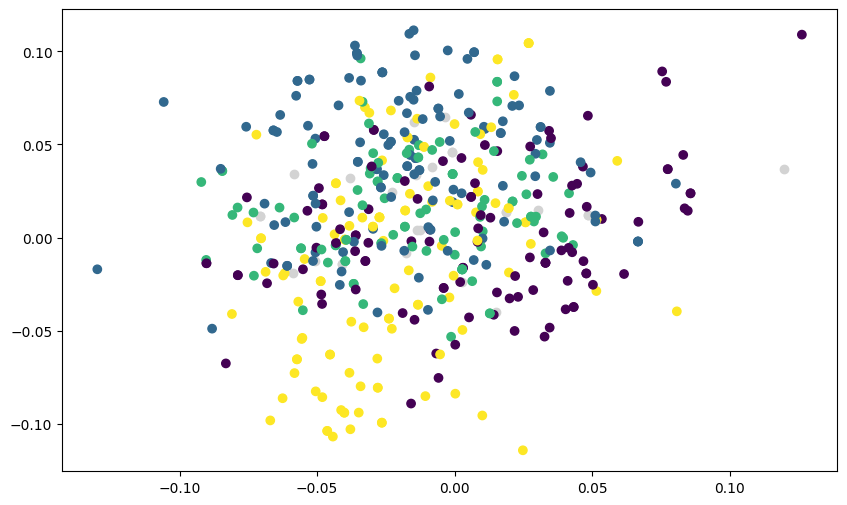

In [21]:
noise = labels == -1
plt.figure(figsize = (10,6))
plt.scatter(embeddings[noise,0], embeddings[noise,1], color = "lightgray", label = "Noise")
plt.scatter(embeddings[~noise,0], embeddings[~noise,1], c = labels[~noise],label = "Cluster")


In [22]:
df_labels

,label
0,-1
1,2
2,3
3,3
4,1
...,...
478,0
479,3
480,0
481,2


In [23]:
df["cluster"] = labels
df

,customer_id,timestamp,channel,raw_text,sentiment,emotion,cluster
0,1085,2024-06-01 13:51:00,Social Media (X/Twitter),The digital membership scanner loaded the basi...,neutral,neutral,-1
1,4724,2024-06-01 10:40:00,Social Media (X/Twitter),The digital checkout screen is incredibly intu...,positive,neutral,2
2,7601,2024-06-01 13:17:00,Social Media (X/Twitter),The cardboard shipping box arrived completely ...,negative,anger,3
3,2241,2024-06-01 15:05:00,Social Media (X/Twitter),The order confirmation system kept the items p...,neutral,neutral,3
4,6966,2024-06-01 17:14:00,Social Media (X/Twitter),The floor staff working today helped me find e...,neutral,neutral,1
...,...,...,...,...,...,...,...
478,7548,2026-04-04 17:46:00,Call Center Transcript,The physical shelves for the new collection we...,positive,neutral,0
479,1031,2026-04-28 19:48:00,Call Center Transcript,The standard delivery transit timeframe update...,positive,neutral,3
480,8526,2026-04-28 20:26:00,Call Center Transcript,The stock levels for advertised sale items mat...,neutral,neutral,0
481,5181,2026-04-28 12:53:00,Call Center Transcript,The digital membership scanner worked perfectl...,positive,neutral,2


In [24]:
df["cluster"].unique()

array([-1,  2,  3,  1,  0])

In [25]:
# Step 6: We now have the clusters, so we can do further textual analysis to find the common themes, and identify a tag
from keybert import KeyBERT
kw_model = KeyBERT()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6030.08it/s]


In [39]:
df_cluster0 = df[df.cluster == 0]
keywords_cluster0 = kw_model.extract_keywords(df_cluster0["raw_text"].tolist(), keyphrase_ngram_range=(1,3))
keywords_cluster0

[[('stock levels advertised', 0.6216),
  ('levels advertised sale', 0.56),
  ('stock levels', 0.5231),
  ('advertised sale items', 0.5061),
  ('sale items beautifully', 0.4755)],
 [('online availability tracker', 0.6695),
  ('matched digital inventory', 0.6624),
  ('digital inventory perfectly', 0.6377),
  ('digital inventory', 0.6089),
  ('availability tracker', 0.6014)],
 [('stock levels advertised', 0.6263),
  ('basic pieces unique', 0.5897),
  ('advertised sale items', 0.5683),
  ('levels advertised sale', 0.5634),
  ('stock levels', 0.5362)],
 [('physical shelves new', 0.688),
  ('shelves new collection', 0.6344),
  ('physical shelves', 0.6175),
  ('shelves new', 0.5982),
  ('new collection looked', 0.5633)],
 [('online availability tracker', 0.6374),
  ('digital inventory perfectly', 0.6333),
  ('matched digital inventory', 0.6283),
  ('availability tracker matched', 0.5943),
  ('availability tracker', 0.5754)],
 [('display center aisle', 0.6036),
  ('digital inventory perfectly'

## Cluster 0: Inventory

In [40]:
df_cluster1 = df[df.cluster == 1]
keywords_cluster1 = kw_model.extract_keywords(df["raw_text"].tolist(), keyphrase_ngram_range=(1,3))
keywords_cluster1

[[('digital checkout screen', 0.74),
  ('checkout screen incredibly', 0.7138),
  ('digital checkout', 0.6566),
  ('checkout screen', 0.6212),
  ('screen incredibly intuitive', 0.5737)],
 [('crushed smashed box', 0.7487),
  ('smashed box left', 0.6998),
  ('smashed box', 0.6947),
  ('cardboard shipping box', 0.6732),
  ('cardboard shipping', 0.6495)],
 [('safe secure box', 0.6474),
  ('secure box left', 0.6412),
  ('confirmation kept items', 0.6146),
  ('secure box', 0.6015),
  ('order confirmation kept', 0.5777)],
 [('floor staff working', 0.5089),
  ('instantly issues report', 0.4666),
  ('issues report', 0.4289),
  ('helped instantly issues', 0.4017),
  ('working today helped', 0.4016)],
 [('digital membership scanner', 0.7032),
  ('membership scanner worked', 0.7011),
  ('membership scanner', 0.6338),
  ('scanner worked', 0.5884),
  ('scanner worked perfectly', 0.5834)],
 [('stock levels advertised', 0.6216),
  ('levels advertised sale', 0.56),
  ('stock levels', 0.5231),
  ('advert

## Cluster 1: Staff

In [42]:
df_cluster2 = df[df.cluster == 2]
keywords_cluster2 = kw_model.extract_keywords(df["raw_text"].tolist(), keyphrase_ngram_range=(1,3))
keywords_cluster2

[[('digital checkout screen', 0.74),
  ('checkout screen incredibly', 0.7138),
  ('digital checkout', 0.6566),
  ('checkout screen', 0.6212),
  ('screen incredibly intuitive', 0.5737)],
 [('crushed smashed box', 0.7487),
  ('smashed box left', 0.6998),
  ('smashed box', 0.6947),
  ('cardboard shipping box', 0.6732),
  ('cardboard shipping', 0.6495)],
 [('safe secure box', 0.6474),
  ('secure box left', 0.6412),
  ('confirmation kept items', 0.6146),
  ('secure box', 0.6015),
  ('order confirmation kept', 0.5777)],
 [('floor staff working', 0.5089),
  ('instantly issues report', 0.4666),
  ('issues report', 0.4289),
  ('helped instantly issues', 0.4017),
  ('working today helped', 0.4016)],
 [('digital membership scanner', 0.7032),
  ('membership scanner worked', 0.7011),
  ('membership scanner', 0.6338),
  ('scanner worked', 0.5884),
  ('scanner worked perfectly', 0.5834)],
 [('stock levels advertised', 0.6216),
  ('levels advertised sale', 0.56),
  ('stock levels', 0.5231),
  ('advert

## Cluster 2: Delivery

In [43]:
df_cluster3 = df[df.cluster == 3]
keywords_cluster3 = kw_model.extract_keywords(df_cluster3["raw_text"].tolist(), keyphrase_ngram_range=(1,3))
keywords_cluster3

[[('crushed smashed box', 0.7487),
  ('smashed box left', 0.6998),
  ('smashed box', 0.6947),
  ('cardboard shipping box', 0.6732),
  ('cardboard shipping', 0.6495)],
 [('safe secure box', 0.6474),
  ('secure box left', 0.6412),
  ('confirmation kept items', 0.6146),
  ('secure box', 0.6015),
  ('order confirmation kept', 0.5777)],
 [('box updated tracking', 0.626),
  ('updated tracking alerts', 0.5882),
  ('cardboard shipping box', 0.5679),
  ('shipping box updated', 0.5504),
  ('cardboard shipping', 0.5298)],
 [('absolutely order online', 0.6825),
  ('order online', 0.6775),
  ('order confirmation', 0.6208),
  ('order confirmation showed', 0.6144),
  ('courier distribution absolutely', 0.4888)],
 [('package tracking number', 0.6762),
  ('updated tracking alerts', 0.6374),
  ('package tracking', 0.6287),
  ('number updated tracking', 0.6069),
  ('tracking alerts real', 0.5866)],
 [('cardboard shipping box', 0.714),
  ('cardboard shipping', 0.698),
  ('shipping box updated', 0.6513),
 

## Cluster 3: Technology

In [30]:
# Remove noise
df = df[df.cluster != -1]
df

,customer_id,timestamp,channel,raw_text,sentiment,emotion,cluster
1,4724,2024-06-01 10:40:00,Social Media (X/Twitter),The digital checkout screen is incredibly intu...,positive,neutral,2
2,7601,2024-06-01 13:17:00,Social Media (X/Twitter),The cardboard shipping box arrived completely ...,negative,anger,3
3,2241,2024-06-01 15:05:00,Social Media (X/Twitter),The order confirmation system kept the items p...,neutral,neutral,3
4,6966,2024-06-01 17:14:00,Social Media (X/Twitter),The floor staff working today helped me find e...,neutral,neutral,1
5,3719,2024-06-01 16:57:00,Social Media (X/Twitter),The digital membership scanner worked perfectl...,positive,neutral,2
...,...,...,...,...,...,...,...
478,7548,2026-04-04 17:46:00,Call Center Transcript,The physical shelves for the new collection we...,positive,neutral,0
479,1031,2026-04-28 19:48:00,Call Center Transcript,The standard delivery transit timeframe update...,positive,neutral,3
480,8526,2026-04-28 20:26:00,Call Center Transcript,The stock levels for advertised sale items mat...,neutral,neutral,0
481,5181,2026-04-28 12:53:00,Call Center Transcript,The digital membership scanner worked perfectl...,positive,neutral,2


In [31]:
# Now we will add our labels 
label_map = {
    0: "Inventory",
    1: "Staff",
    2: "Delivery",
    3: "Technology"
}
df["label"] = df["cluster"].map(label_map)
df


C:\Users\yashi\AppData\Local\Temp\ipykernel_17992\4255982017.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = df["cluster"].map(label_map)


,customer_id,timestamp,channel,raw_text,sentiment,emotion,cluster,label
1,4724,2024-06-01 10:40:00,Social Media (X/Twitter),The digital checkout screen is incredibly intu...,positive,neutral,2,Delivery
2,7601,2024-06-01 13:17:00,Social Media (X/Twitter),The cardboard shipping box arrived completely ...,negative,anger,3,Technology
3,2241,2024-06-01 15:05:00,Social Media (X/Twitter),The order confirmation system kept the items p...,neutral,neutral,3,Technology
4,6966,2024-06-01 17:14:00,Social Media (X/Twitter),The floor staff working today helped me find e...,neutral,neutral,1,Staff
5,3719,2024-06-01 16:57:00,Social Media (X/Twitter),The digital membership scanner worked perfectl...,positive,neutral,2,Delivery
...,...,...,...,...,...,...,...,...
478,7548,2026-04-04 17:46:00,Call Center Transcript,The physical shelves for the new collection we...,positive,neutral,0,Inventory
479,1031,2026-04-28 19:48:00,Call Center Transcript,The standard delivery transit timeframe update...,positive,neutral,3,Technology
480,8526,2026-04-28 20:26:00,Call Center Transcript,The stock levels for advertised sale items mat...,neutral,neutral,0,Inventory
481,5181,2026-04-28 12:53:00,Call Center Transcript,The digital membership scanner worked perfectl...,positive,neutral,2,Delivery


In [32]:
embeddings_clean = embeddings[labels != -1]
df_embeddings_clean = pd.DataFrame(embeddings_clean)
df_embeddings_clean["cluster"] = df["cluster"].values

In [33]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df_embeddings_clean.drop("cluster", axis = 1), df_embeddings_clean["cluster"], test_size = 0.2, random_state = 107)

In [34]:
# Step 7: Why don't we now create a intent classification model for future data, we will use SVM as it is a powerful tool to create distinct seperation of categories
from sklearn import svm
support_vector = svm.SVC(kernel = "linear")
svm_fit = support_vector.fit(x_train, y_train)
svm_fit

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [35]:
predictions = svm_fit.predict(x_test)


In [36]:
from sklearn.metrics import confusion_matrix, accuracy_score
confusion_matrix(y_test, predictions)

array([[17,  0,  0,  0],
       [ 0, 28,  0,  0],
       [ 0,  0, 18,  0],
       [ 0,  0,  0, 29]])

In [37]:
accuracy_score(y_test, predictions)

1.0

In [38]:
## We will Save our CSV so then we can do dashboarding
csv = df.to_csv("Customer_insight.csv", index = False)

PermissionError: [Errno 13] Permission denied: 'Customer_insight.csv'